[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/openquantumhardware/qick/blob/merge-hrl-main/emulator/notebooks/tutorial/07_Advanced_Generators_And_Readouts_emu.ipynb)

# 07 - Advanced Generators and Readouts in tProc v2 (Emulator Edition)

**Objective:** Explore the advanced generator and readout blocks available in the QICK firmware -- running against the Verilator emulator instead of a physical RFSoC. This notebook covers:

1. Muxed Generators (full-speed) with Muxed Readouts (PFB)
2. ~~Interpolated Generators vs. Standard Readouts~~ (skipped -- not modeled by the emulator)
3. Dynamically Configured Readouts for frequency sweeps and electrical delay calibration
4. ~~Fast Dynamic Readout~~ (skipped -- not modeled by the emulator)
5. IQ offset measurement and correction
6. Performance benchmarks (reframed -- these measure Verilator simulation throughput, not hardware acquisition speed)
7. Real-time phase tracking
8. Common pitfalls and troubleshooting
9. Best practices summary

This is a 1:1 port of the on-hardware tutorial `07_Advanced_Generators_And_Readouts.ipynb` (mirrored under [`../../docs/source/tutorials/`](../../docs/source/tutorials/) in this repo), with the adaptations above. `qick_emu_config.json`'s testbench instantiates a **reduced** set of IP blocks compared to real ZCU216 firmware -- 3 generator instances and 6 readout instances, none of them an interpolated generator, mixer-mux generator, or fast-dynamic (`axis_readout_v3`) readout. Where a section depends on one of those missing blocks, it's replaced with a short note rather than a broken cell. Everything else runs for real against the emulator.

**Prerequisites:** Complete the introductory tutorials ([`00_Getting_Started_emu.ipynb`](./00_Getting_Started_emu.ipynb) through [`06_Generators_And_Readouts_emu.ipynb`](./06_Generators_And_Readouts_emu.ipynb)).

## 0. Colab Setup

Skip this cell if you're running locally with the `qick-venv` kernel (see [`emulator/README.md`](https://github.com/openquantumhardware/qick/blob/merge-hrl-main/emulator/README.md)) -- it's a no-op there. In Google Colab it clones this repo, builds Verilator 5.042 from source, and installs the Python dependencies. **First run takes a few minutes** (compiling Verilator); re-running later cells, or reconnecting to the same runtime, reuses what's already built.

In [ ]:
import os
import sys
import pathlib
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def run(cmd, **kwargs):
    """Run a shell command, streaming output, and raise loudly on failure.

    Using this instead of bare `!command` / get_ipython().system() so a
    failure here stops the bootstrap immediately with a real traceback,
    instead of silently letting later cells fail with a confusing
    ModuleNotFoundError.
    """
    print(f"+ {cmd}")
    result = subprocess.run(cmd, shell=True, **kwargs)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (rc={result.returncode}): {cmd}")


if IN_COLAB:
    REPO_URL = "https://github.com/openquantumhardware/qick.git"
    REPO_BRANCH = "merge-hrl-main"
    REPO_DIR = pathlib.Path("/content/qick")

    if not REPO_DIR.exists():
        print(f"Cloning {REPO_URL} @ {REPO_BRANCH} ...")
        run(f"git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}")
    os.chdir(REPO_DIR)

    print("Fetching git submodules (Verilator source, AXI/common_cells) ...")
    run("git submodule update --init --recursive --depth 1")

    verilator_ok = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
    if "5.042" not in verilator_ok.stdout:
        print("Installing build dependencies (apt) ...")
        run("DEBIAN_FRONTEND=noninteractive apt-get -qq update")
        run(
            "DEBIAN_FRONTEND=noninteractive apt-get -qq install -y "
            "git help2man perl python3 make autoconf g++ flex bison ccache "
            "libgoogle-perftools-dev numactl perl-doc libfl-dev zlib1g-dev"
        )

        print("Building Verilator 5.042 from source (a few minutes, first run only) ...")
        os.chdir(REPO_DIR / "emulator" / "submodules" / "verilator")
        run("autoconf")
        run("./configure")
        run("make -j$(nproc)")
        run("make install")
        os.chdir(REPO_DIR)
        verilator_ok = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
        if "5.042" not in verilator_ok.stdout:
            raise RuntimeError(
                "Verilator build finished but 'verilator --version' still doesn't "
                f"report 5.042 (got: {verilator_ok.stdout!r} / {verilator_ok.stderr!r})"
            )
        print(verilator_ok.stdout)
    else:
        print("Verilator 5.042 already installed, skipping build.")

    # Scientific-Python deps only -- NOT jupyter/ipykernel, which would fight
    # with Colab's own kernel runtime. `emulator/requirements.txt` is for the
    # local venv+Jupyter setup (see emulator/README.md); Colab needs a subset.
    print("Installing Python dependencies ...")
    run("pip install numpy scipy matplotlib tqdm")
    run("pip install -e .")

    # Belt-and-suspenders: insert the source dirs directly, so `import qick`
    # works below even if pip's editable-install .pth file isn't picked up by
    # this already-running interpreter (a known Colab quirk).
    for rel in ("qick_lib", "emulator/software"):
        p = str(REPO_DIR / rel)
        if p not in sys.path:
            sys.path.insert(0, p)

    os.chdir(REPO_DIR / "emulator" / "notebooks" / "tutorial")

    # Verify right here, in this cell, instead of letting a failure surface
    # one cell later as a confusing ModuleNotFoundError.
    import importlib
    importlib.invalidate_caches()
    try:
        import qick
        print(f"\nColab setup complete. qick {qick.get_version()} importable from {qick.__file__}")
    except ImportError as e:
        raise RuntimeError(
            f"Setup finished but 'import qick' still fails ({e}). "
            f"cwd={pathlib.Path.cwd()}, REPO_DIR contents: {list(REPO_DIR.iterdir())}"
        ) from e
    print(f"Working directory: {pathlib.Path.cwd()}")
else:
    print("Not running in Colab -- skipping clone/build (using the local checkout as-is).")


## 1. Setup

In [2]:
# Jupyter notebook setup
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sys
import pathlib
import logging
import time

# Local qick_lib / emulator path setup (see emulator/notebooks/00_intro_emu.ipynb)
REPO_ROOT = pathlib.Path.cwd().parent.parent   # emulator/ (tutorial/ nests one level deeper)
sys.path.insert(0, str(REPO_ROOT / '..' / 'qick_lib'))
sys.path.insert(0, str(REPO_ROOT / 'software'))

import qick
from qick import *
from qick.asm_v2 import AveragerProgramV2, QickSweep1D, AsmV2

from qick_emu import QickEmu

logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')

# --- No firmware .bit file or physical board needed ---
CFG_PATH = REPO_ROOT / 'config' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# Channel constants -- adapted to what qick_emu_config.json's testbench actually
# instantiates. Real ZCU216 firmware has 5 generator types and 7 readout types;
# the emulator models a reduced subset (3 gens, 6 readouts):
#   gen 0: axis_signal_gen_v6 (full-speed)
#   gen 1: axis_signal_gen_v6 (full-speed) -- a second full-speed gen, standing in
#          for what would be INTGEN_CH on hardware (the emulator has no
#          axis_sg_int4_v2 interpolated generator -- see Section 4 below)
#   gen 2: axis_sg_mux8_v1 (full-speed mux, 8 tones) -- there is no separate
#          mixer-mux (axis_sg_mixmux8_v1) generator -- see Section 3.2 below
#   ro  0: axis_dyn_readout_v1 (dynamic)
#   ro  1: axis_readout_v2 (standard) -- there is no axis_readout_v3
#          "fast dynamic" readout -- see Section 6 below
#   ro  2-5: axis_pfb_readout_v3 x4 (muxed PFB)
FSGEN_CH  = 0            # Full-speed generator
FSGEN2_CH = 1            # Second full-speed generator (no interpolated gen available)
FSMUXGEN_CH = 2          # Full-speed mux generator (8 tones, phase coherent)

DYNRO_CH  = 0            # Dynamically configured readout (axis_dyn_readout_v1)
MUXRO_CH  = [2, 3]       # Muxed readout channels (PFB). The testbench's avg/dec
                         # CSV capture only covers readout indices 0-3 (dyn, std,
                         # and 2 of the 4 PFB instances) -- ro 4/5 exist on the AXI
                         # bus but acquire()/acquire_decimated() can't read them
                         # back. Same limit already applied in 01_gens-and-readouts.ipynb.
STDRO_CH  = 1            # Standard readout (axis_readout_v2)

print(f"Available generators (DACs): {list(range(len(soccfg['gens'])))}")
print(f"Available readouts (ADCs): {list(range(len(soccfg['readouts'])))}")
print(f"tProc core version: {soccfg['tprocs'][0]['version']}")
print(f"Software version: {soccfg['sw_version']}")

ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '07_advanced_generators_and_readouts'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Artifacts -> {ARTIFACTS_ROOT}')

# EMULATOR NOTE (applies to the whole notebook): Verilator simulates at roughly
# 10-15us of device time per second of wall-clock time (see 00_Getting_Started_emu.ipynb's
# smoke test: ~13.5 us/s). That means large `reps`/`steps` sweeps that are cheap on
# real hardware can be very slow here -- every sweep below is shrunk accordingly,
# with a note explaining the shrink. It also means the simulation is fully
# deterministic given fixed inputs: repeating an identical shot doesn't add
# statistical noise averaging the way it does on hardware, so shot-to-shot
# "noise" sections (Sections 7, 9) will show much tighter spreads here than on
# a real board.

WARNING  [qick_asm.py:49] QICK library version mismatch: 0.2.366 remote (the board), 0.2.88 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Available generators (DACs): [0, 1, 2]
Available readouts (ADCs): [0, 1, 2, 3, 4, 5]
tProc core version: 2.0
Software version: 0.2.366
Artifacts -> /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/07_advanced_generators_and_readouts


In [3]:
print("=== Readouts (ADCs) Hardware Identification ===")
for i, ro in enumerate(soccfg['readouts']):
    ro_kind = ro.get('ro_type', 'Unknown RO')
    buf_kind = ro.get('avgbuf_type', 'Unknown Buffer')
    ro_ver = ro.get('ro_version', 'N/A')

    print(f"RO {i}:")
    print(f"  - Readout Type: {ro_kind} (v{ro_ver})")
    print(f"  - Buffer Type:  {buf_kind}")
    print(f"  - Decimation:   {ro.get('decimation', 'N/A')}")
    print(f"  - Sampling Freq: {ro.get('fs', 'N/A')} MHz")
    print("-" * 30)

=== Readouts (ADCs) Hardware Identification ===
RO 0:
  - Readout Type: axis_dyn_readout_v1 (v1.0)
  - Buffer Type:  axis_avg_buffer
  - Decimation:   1
  - Sampling Freq: 2457.6 MHz
------------------------------
RO 1:
  - Readout Type: axis_readout_v2 (v1.0)
  - Buffer Type:  axis_avg_buffer
  - Decimation:   1
  - Sampling Freq: 2457.6 MHz
------------------------------
RO 2:
  - Readout Type: axis_pfb_readout_v3 (v1.0)
  - Buffer Type:  axis_avg_buffer
  - Decimation:   2
  - Sampling Freq: 2457.6 MHz
------------------------------
RO 3:
  - Readout Type: axis_pfb_readout_v3 (v1.0)
  - Buffer Type:  axis_avg_buffer
  - Decimation:   2
  - Sampling Freq: 2457.6 MHz
------------------------------
RO 4:
  - Readout Type: axis_pfb_readout_v3 (v1.0)
  - Buffer Type:  axis_avg_buffer
  - Decimation:   2
  - Sampling Freq: 2457.6 MHz
------------------------------
RO 5:
  - Readout Type: axis_pfb_readout_v3 (v1.0)
  - Buffer Type:  axis_avg_buffer
  - Decimation:   2
  - Sampling Freq: 24

## 2. Generator and Readout Types Overview

Understanding the different generator and readout types is crucial for optimal performance. (Reference table -- types marked "not in emulator" below aren't instantiated by `qick_emu_config.json`'s testbench; see Section 1.)

In [4]:
print("""
+------------------------------------------------------------------------------------------------------------+
|                                         GENERATOR TYPES                                                      |
+------------------------+---------------------------------------------------------------------------------+
| Generator Type         | Best For                                                                       |
+------------------------+---------------------------------------------------------------------------------+
| Full-Speed (FS)        | Single tone, maximum bandwidth (10 Gsps), simple pulses                       |
| Interpolated (INT)     | Fine frequency resolution, needs mixer_freq for upconversion (not in emulator)|
| Full-Speed Mux (FSMUX) | Multi-tone, phase-coherent, up to 8 tones @ 10 Gsps, constant envelope        |
| Mixer-Mux (MIXMUX)     | Multi-tone, phase-coherent, lower sample rate, better SFDR (not in emulator)  |
+------------------------+---------------------------------------------------------------------------------+
|                                         READOUT TYPES                                                        |
+------------------------+---------------------------------------------------------------------------------+
| Readout Type           | Best For                                                                       |
+------------------------+---------------------------------------------------------------------------------+
| Standard (STD)         | Fixed frequency readout, simple averaging                                     |
| Dynamic (DYN)          | Sweeping frequencies, resonator spectroscopy, delay calibration               |
| Fast Dynamic (FASTDYN) | Phase-reset applications, fast sequencing (not in emulator)                   |
| Muxed PFB (MUX)        | Multi-tone readout, simultaneous demodulation                                 |
+------------------------+---------------------------------------------------------------------------------+
""")


+------------------------------------------------------------------------------------------------------------+
|                                         GENERATOR TYPES                                                      |
+------------------------+---------------------------------------------------------------------------------+
| Generator Type         | Best For                                                                       |
+------------------------+---------------------------------------------------------------------------------+
| Full-Speed (FS)        | Single tone, maximum bandwidth (10 Gsps), simple pulses                       |
| Interpolated (INT)     | Fine frequency resolution, needs mixer_freq for upconversion (not in emulator)|
| Full-Speed Mux (FSMUX) | Multi-tone, phase-coherent, up to 8 tones @ 10 Gsps, constant envelope        |
| Mixer-Mux (MIXMUX)     | Multi-tone, phase-coherent, lower sample rate, better SFDR (not in emulator)  |
+--------------------

## 3. Muxed Generators and Muxed Readouts (PFB)

Muxed generators allow you to play multiple tones simultaneously, and muxed readouts (PFB) can demodulate them efficiently.

**Key concepts:**
- The `mask` parameter in `add_pulse` selects which tones are played
- The PFB readout provides finer channel spacing than standard muxed readout
- Linking generators to readouts with `gen_ch` enables automatic frequency matching

**Emulator note:** the on-hardware version uses `MIXMUXGEN_CH` (mixer-mux generator, `axis_sg_mixmux8_v1`). The emulator only instantiates the full-speed mux generator (`axis_sg_mux8_v1`), so we use `FSMUXGEN_CH` instead and drop the `mixer_freq` argument (full-speed mux has no mixer) -- same substitution already used successfully in [`01_gens-and-readouts.ipynb`](../01_gens-and-readouts.ipynb)'s `MuxProgram`.

Running muxed generator with PFB readout...
[sim] Running simulation with EMU_DIR=../../artifacts/07_advanced_generators_and_readouts/mux_pfb ...


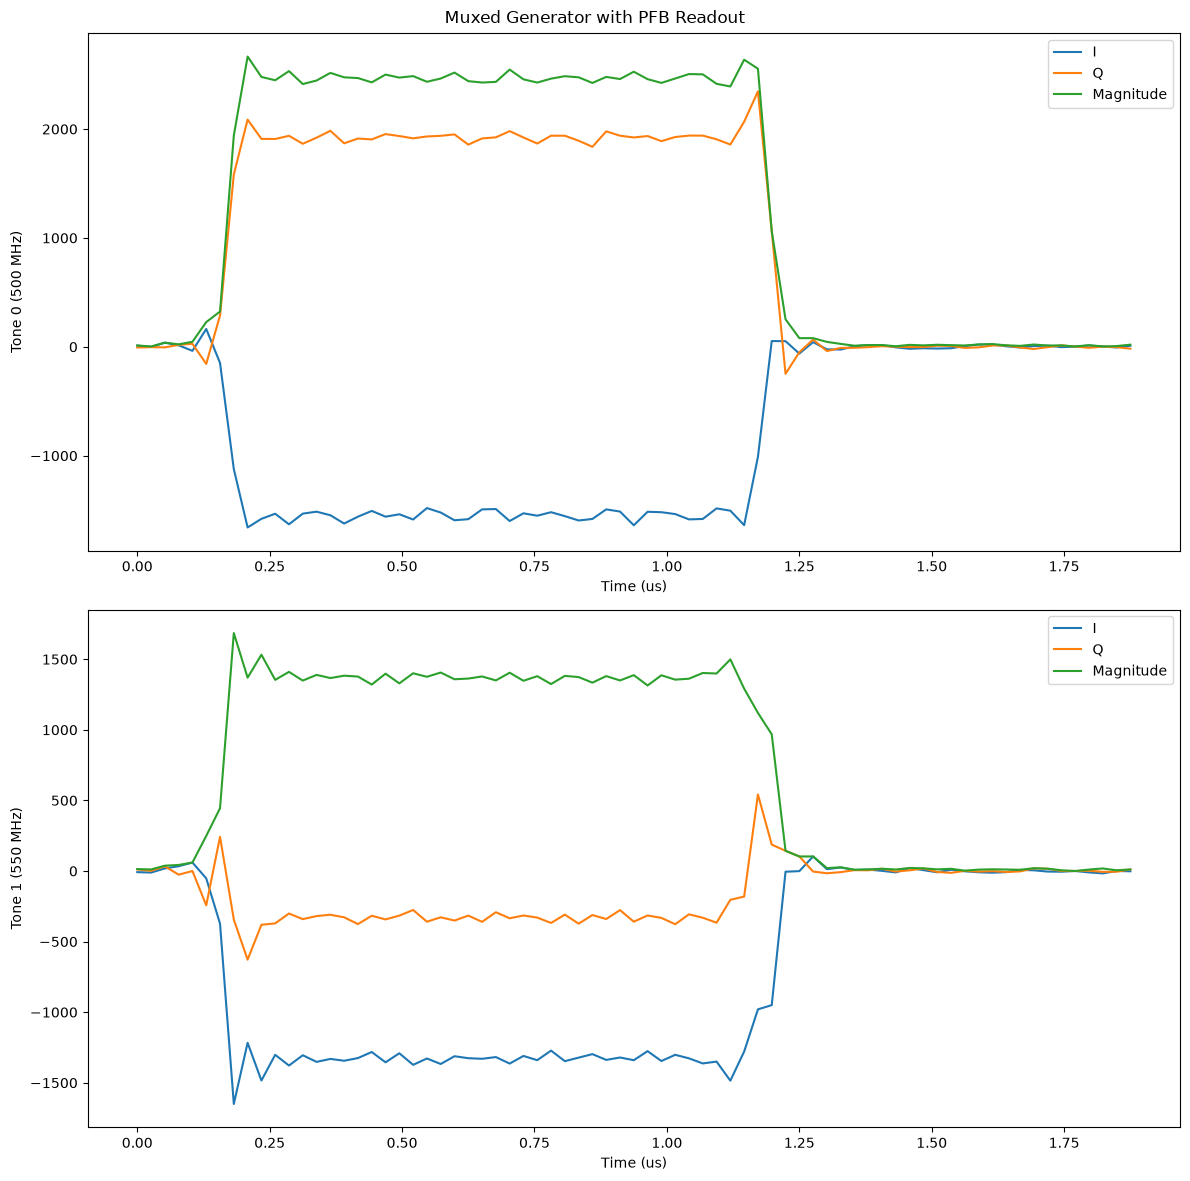

In [5]:
class MuxProgram(AveragerProgramV2):
    """
    Program demonstrating muxed generator with PFB readout.
    Plays multiple tones simultaneously on a single DAC channel.
    """
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        gen_ch = cfg['gen_ch']

        # Declare a muxed generator with multiple tones
        # The 'ro_ch' argument links it to a readout for frequency matching
        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_chs[0],
                         mux_freqs=cfg['pulse_freqs'],
                         mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'])

        # Declare each PFB readout channel, linking back to the same generator
        # This automatically matches readout frequencies to generator tones
        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=gen_ch)

        # Create a constant pulse that plays on all 4 tones simultaneously
        # The 'mask' parameter selects which tone indices to enable
        self.add_pulse(ch=gen_ch, name="mymux",
                       style="const",
                       length=cfg["pulse_len"],
                       mask=[0, 1],  # both declared tones
                      )

    def _body(self, cfg):
        # NB: ddr4=True is a no-op in the emulator, kept for parity with hardware.
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name="mymux", t=0)

# Configuration for the program
config_mux = {
    'gen_ch': FSMUXGEN_CH,
    'ro_chs': MUXRO_CH,
    'pulse_freqs': [500, 550],  # MHz -- only 2 tones, see the MUXRO_CH note in Section 1
    'pulse_gains': [1.0] * 2,
    'pulse_phases': [0.0] * 2,
    'ro_phases': [0.0] * 2,               # Initial downconversion phases
    'trig_time': 0.4,                    # us, trigger before pulse
    'pulse_len': 1.0,                    # us
    'ro_len': 1.9,                       # us, readout length
}

print("Running muxed generator with PFB readout...")
prog = MuxProgram(soccfg, reps=1, final_delay=0.5, cfg=config_mux)

OUT = ARTIFACTS_ROOT / 'mux_pfb'
OUT.mkdir(parents=True, exist_ok=True)

# First simulation of the kernel session: build=True runs `make verilate`.
# It only needs to happen once per session -- see the PERFORMANCE NOTE in
# 00_intro_emu.ipynb for the build=False pattern used from here on.
soc = soc.prepare_emu(memdir=OUT, build=True)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

# Plot results for each readout channel
fig, axes = plt.subplots(len(config_mux['ro_chs']), 1, figsize=(12, 12))
for i, ch in enumerate(config_mux['ro_chs']):
    axes[i].plot(t, iq_list[i][:, 0], label="I")
    axes[i].plot(t, iq_list[i][:, 1], label="Q")
    axes[i].plot(t, np.abs(iq_list[i].dot([1, 1j])), label="Magnitude")
    axes[i].legend()
    axes[i].set_ylabel(f"Tone {i} ({config_mux['pulse_freqs'][i]} MHz)")
    axes[i].set_xlabel("Time (us)")
plt.suptitle("Muxed Generator with PFB Readout")
plt.tight_layout()

### 3.1 Correcting IQ Phase Offsets

The raw IQ data is rotated due to cable delays and mixer imperfections. We can correct this by measuring the average phase and applying a correction to either the upconversion (pulse) phase or the downconversion (readout) phase.

Phase offsets: [np.float64(127.98440739908743), np.float64(-167.60013646952353)]
[sim] Running simulation with EMU_DIR=../../artifacts/07_advanced_generators_and_readouts/mux_pfb ...


[sim] Running simulation with EMU_DIR=../../artifacts/07_advanced_generators_and_readouts/mux_pfb ...


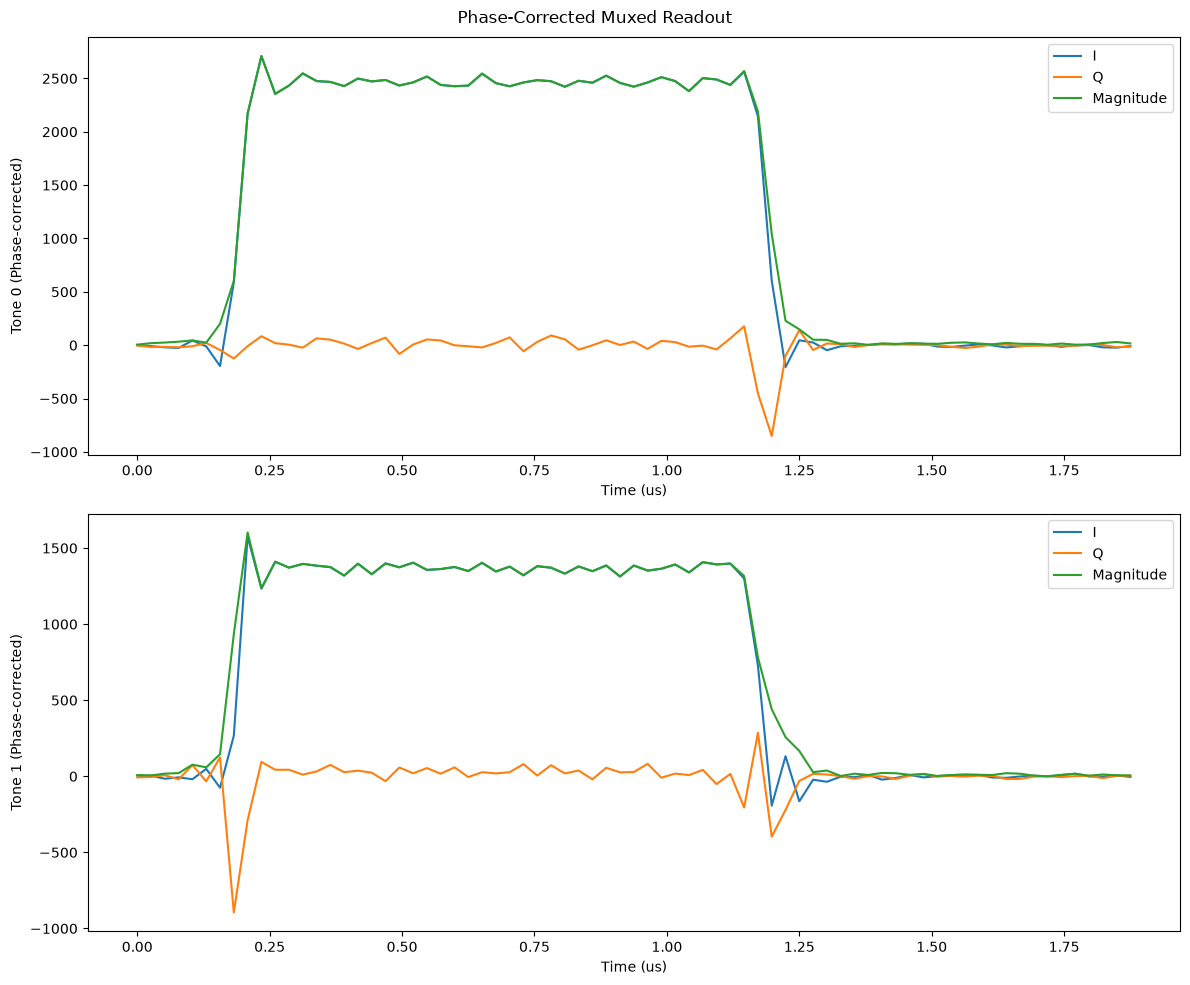

In [6]:
# Calculate average phase offset for each channel (in degrees)
phases = [np.angle(iq.mean(axis=0).dot([1, 1j]), deg=True) for iq in iq_list]
print(f"Phase offsets: {phases}")

# Option 1: Rotate the upconversion phase
config_mux['pulse_phases'] = [-x for x in phases]
prog = MuxProgram(soccfg, reps=1, final_delay=0.5, cfg=config_mux)
soc = soc.prepare_emu(memdir=OUT, build=False)
iq_list_corrected_up = prog.acquire_decimated(soc, rounds=1)

# Option 2: Rotate the downconversion phase
config_mux['pulse_phases'] = [0.0] * 2
config_mux['ro_phases'] = phases
prog = MuxProgram(soccfg, reps=1, final_delay=0.5, cfg=config_mux)
soc = soc.prepare_emu(memdir=OUT, build=False)
iq_list_corrected_down = prog.acquire_decimated(soc, rounds=1)

# Plot corrected data (Option 2 as example)
fig, axes = plt.subplots(len(config_mux['ro_chs']), 1, figsize=(12, 10))
for i, ch in enumerate(config_mux['ro_chs']):
    axes[i].plot(t, iq_list_corrected_down[i][:, 0], label="I")
    axes[i].plot(t, iq_list_corrected_down[i][:, 1], label="Q")
    axes[i].plot(t, np.abs(iq_list_corrected_down[i].dot([1, 1j])), label="Magnitude")
    axes[i].legend()
    axes[i].set_ylabel(f"Tone {i} (Phase-corrected)")
    axes[i].set_xlabel("Time (us)")
plt.suptitle("Phase-Corrected Muxed Readout")
plt.tight_layout()

### 3.2 Mixer-Mux Generator Example

**Skipped on the emulator.** The mixer-mux generator (`axis_sg_mixmux8_v1`) is not instantiated by `qick_emu_config.json`'s testbench -- only the full-speed mux generator (`axis_sg_mux8_v1`, used above as `FSMUXGEN_CH`) is available. On real hardware, this section would compare the two mux architectures (mixer-mux trades sample rate for better SFDR); on the emulator there's only one to demonstrate.

### 3.3 Playing Different Tone Combinations

You can selectively enable tones using different masks.

Running selective tone playback...
[sim] Running simulation with EMU_DIR=../../artifacts/07_advanced_generators_and_readouts/mux_pfb ...


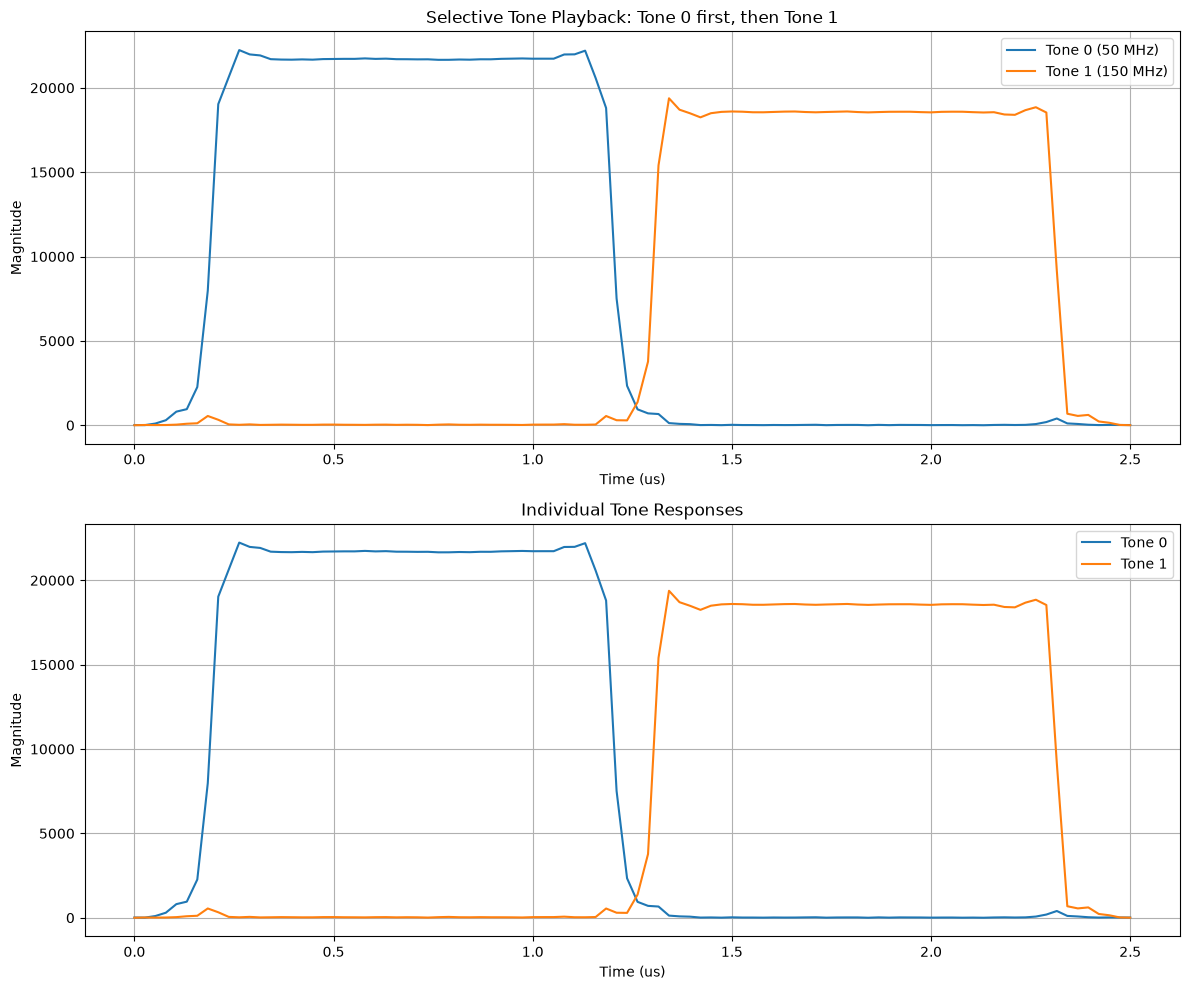

In [7]:
class MuxProgramSelective(AveragerProgramV2):
    """Program demonstrating selective tone playback using masks."""

    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_chs[0],
                         mux_freqs=cfg['pulse_freqs'],
                         mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'])

        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=gen_ch)

        # Add multiple pulses with different masks (only tones 0/1 are declared
        # -- see the MUXRO_CH note in Section 1 -- so each pulse plays one tone)
        self.add_pulse(ch=gen_ch, name="tone0",
                       style="const", length=cfg["pulse_len"],
                       mask=[0])

        self.add_pulse(ch=gen_ch, name="tone1",
                       style="const", length=cfg["pulse_len"],
                       mask=[1])

    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
        # First pulse (tone 0 only)
        self.pulse(ch=cfg['gen_ch'], name="tone0", t=0)
        # Second pulse starts after first finishes (tone 1 only)
        self.pulse(ch=cfg['gen_ch'], name="tone1", t=cfg['pulse_len'] + 0.1)

config_selective = {
    'gen_ch': FSMUXGEN_CH,
    'ro_chs': MUXRO_CH,
    'pulse_freqs': [50, 150],
    'pulse_gains': [1.0] * 2,
    'pulse_phases': [0.0] * 2,
    'ro_phases': [0.0] * 2,
    'trig_time': 0.4,
    'pulse_len': 1.0,
    'ro_len': 2.5,
}

print("Running selective tone playback...")
prog_selective = MuxProgramSelective(soccfg, reps=1, final_delay=0.5, cfg=config_selective)
soc = soc.prepare_emu(memdir=OUT, build=False)
iq_list_selective = prog_selective.acquire_decimated(soc, rounds=1)

npts = iq_list_selective[0].shape[0]
t_sel = np.linspace(0, config_selective['ro_len'], npts)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for i, ch in enumerate(config_selective['ro_chs']):
    mag = np.abs(iq_list_selective[i].dot([1, 1j]))
    axes[0].plot(t_sel, mag, label=f"Tone {i} ({config_selective['pulse_freqs'][i]} MHz)")

axes[0].set_ylabel("Magnitude")
axes[0].set_xlabel("Time (us)")
axes[0].legend()
axes[0].set_title("Selective Tone Playback: Tone 0 first, then Tone 1")
axes[0].grid(True)

for i in range(len(config_selective['ro_chs'])):
    mag = np.abs(iq_list_selective[i].dot([1, 1j]))
    axes[1].plot(t_sel, mag, label=f"Tone {i}")

axes[1].set_ylabel("Magnitude")
axes[1].set_xlabel("Time (us)")
axes[1].legend()
axes[1].set_title("Individual Tone Responses")
axes[1].grid(True)

plt.tight_layout()

## 4. Interpolated Generator and Standard Readout

**Skipped on the emulator.** `qick_emu_config.json`'s testbench doesn't instantiate an interpolated generator (`axis_sg_int4_v2`) -- gen 1 (`FSGEN2_CH`) is a second full-speed generator with `has_mixer: False`, so it can't demonstrate the mixer-based absolute-frequency behavior this section is about. The concept still matters for real hardware, so here's the reference table:

### Frequency Matching in tProc v2 vs. tProc v1

| Aspect | tProc v1 | tProc v2 |
|--------|----------|----------|
| Frequency specification | IF (intermediate frequency) | Absolute frequency |
| Mixer frequency handling | User must add to both gen and readout | Automatic |
| Common point of confusion | Forgetting to account for mixer | None (automatic) |

In tProc v2, you specify the **absolute** frequency you want to play. The software automatically calculates the correct IF by subtracting the mixer frequency. The readout frequency is also absolute. (This automatic IF calculation only applies to generators with `has_mixer: True`, i.e. real interpolated generators -- not available in this emulator config.)

## 5. Full-Speed Generator and Dynamically Configured Readout

Dynamically configured readouts allow you to change parameters (like frequency) during a sweep. This is essential for resonator spectroscopy and electrical delay calibration.

**Key steps:**
1. Define a readout configuration using `add_readoutconfig()`
2. Send the configuration using `send_readoutconfig()` before it takes effect
3. For sweeps, send the new configuration in the `exec_before` block of the loop

Running dynamic frequency sweep...
[sim] Running simulation with EMU_DIR=../../artifacts/07_advanced_generators_and_readouts/dynamic_freq_sweep ...


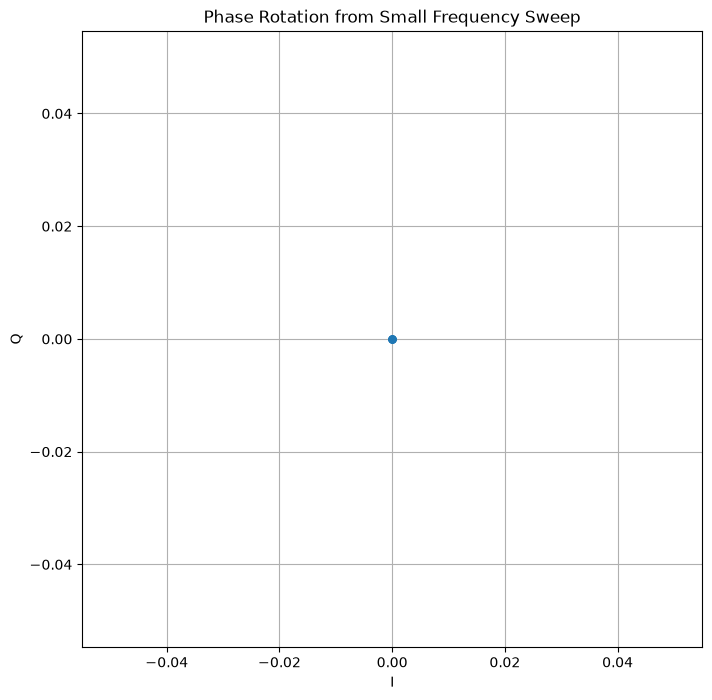

In [8]:
class DynamicFreqSweepProgram(AveragerProgramV2):
    """
    Program demonstrating dynamic readout configuration for frequency sweeps.
    Used for electrical delay calibration and resonator characterization.
    """
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Define the readout configuration (like a pulse for the readout)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch)

        # The exec_before block runs before each loop iteration
        # We use it to send the updated readout config
        loopbefore = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("myloop", self.cfg["steps"], exec_before=loopbefore)

        self.add_gauss(ch=gen_ch, name="ramp", sigma=cfg['ramp_len']/10,
                      length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch,
                       style="flat_top", envelope="ramp",
                       freq=cfg['freq'], length=cfg['flat_len'],
                       phase=cfg['phase'], gain=cfg['gain'])

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# Small frequency sweep to see phase rotation
START_FREQ = 100
CAL_RANGE = 1

config_dyn = {
    'steps': 5,
    'gen_ch': FSGEN_CH,
    'ro_ch': DYNRO_CH,
    'freq': QickSweep1D("myloop", START_FREQ, START_FREQ + CAL_RANGE),
    'nqz': 1,
    'trig_time': 0.4,      # us
    'ro_len': 0.3,         # us
    'flat_len': 0.05,      # us
    'ramp_len': 0.2,       # us
    'phase': 0,
    'gain': 1.0
}

print("Running dynamic frequency sweep...")
prog = DynamicFreqSweepProgram(soccfg, reps=10, final_delay=0.5, cfg=config_dyn)

OUT = ARTIFACTS_ROOT / 'dynamic_freq_sweep'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)

iq_list = prog.acquire(soc, rounds=1)
freqs = prog.get_pulse_param('myro', 'freq', as_array=True)

# The IQ vector rotates as frequency changes due to electrical delay
plt.figure(figsize=(8, 8))
plt.plot(iq_list[0][0][:, 0], iq_list[0][0][:, 1], '.-', markersize=10)
plt.ylabel("Q")
plt.xlabel("I")
plt.title("Phase Rotation from Small Frequency Sweep")
plt.axis('equal')
plt.grid(True)
plt.show()

### 5.1 Electrical Delay Calibration

The phase rotation we observe is due to the electrical delay between the DAC and ADC. By measuring the slope of phase vs. frequency, we can calculate this delay and correct for it.

**Emulator note:** the on-hardware version sweeps `steps=1001` with `reps=100` (100,100 total shots). Verilator simulates at roughly 10-15us of device time per wall-clock second (see the note in Section 1), so that would take on the order of an hour here. We shrink to `steps=41`, `reps=10`.

Performing frequency sweep for delay calibration...
[sim] Running simulation with EMU_DIR=../../artifacts/07_advanced_generators_and_readouts/dynamic_freq_sweep ...


Sweep completed in 5.91 seconds
Measured electrical delay: 0.000000 us
This corresponds to 0.00 ns of cable delay


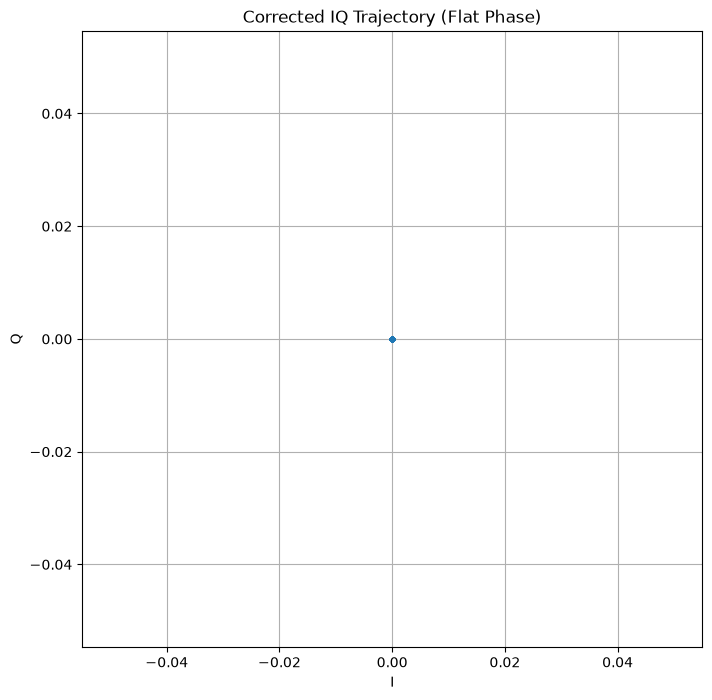

/tmp/ipykernel_736434/1794081909.py:49: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2 = ax1.twinx()


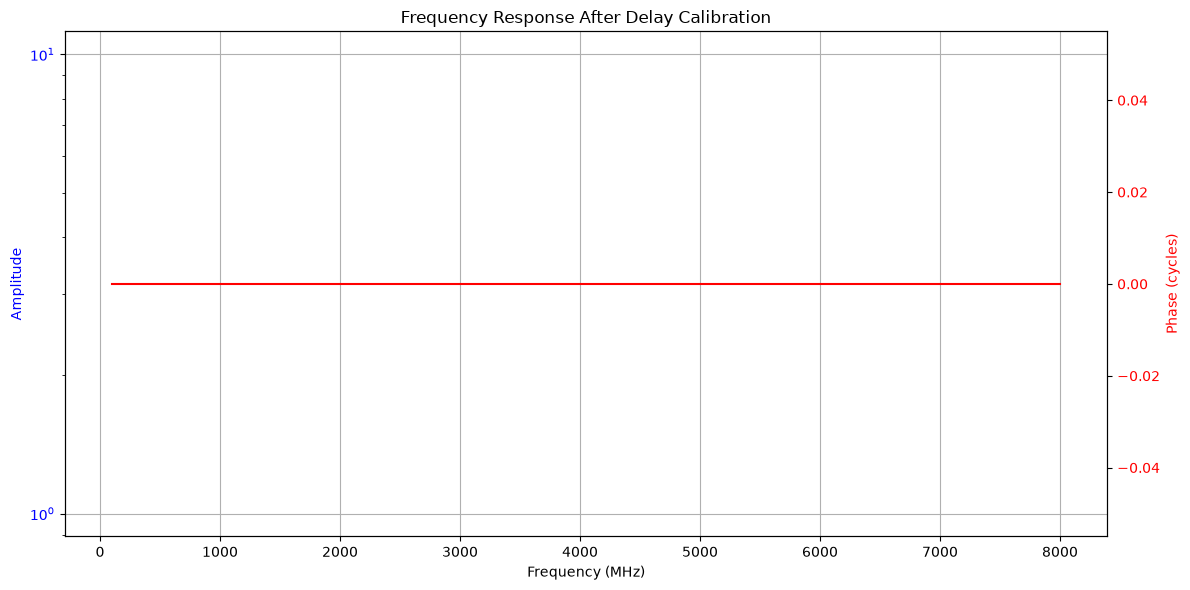

In [9]:
# Perform a wide-range sweep for calibration
# HW version uses steps=1001, reps=100; shrunk for the emulator (see note above).
END_FREQ = 8000  # MHz
config_dyn['freq'] = QickSweep1D("myloop", START_FREQ, END_FREQ)
config_dyn['steps'] = 41

print("Performing frequency sweep for delay calibration...")
prog = DynamicFreqSweepProgram(soccfg, reps=10, final_delay=1.0, cfg=config_dyn)
freqs = prog.get_pulse_param('myro', 'freq', as_array=True)

soc = soc.prepare_emu(memdir=OUT, build=False)

# Acquire data with progress bar
start_time = time.time()
iq_list = prog.acquire(soc, rounds=1, progress=True)
iq_complex = iq_list[0][0].dot([1, 1j])
print(f"Sweep completed in {time.time() - start_time:.2f} seconds")

# Measure the phase slope (electrical delay)
phases = np.unwrap(np.angle(iq_complex)) / (2 * np.pi)
a = np.vstack([freqs, np.ones_like(freqs)]).T
phase_delay = np.linalg.lstsq(a, phases, rcond=None)[0][0]
print(f"Measured electrical delay: {phase_delay:.6f} us")
print(f"This corresponds to {phase_delay * 1e3:.2f} ns of cable delay")

# Apply the correction
iq_rotated = iq_complex * np.exp(-1j * freqs * 2 * np.pi * phase_delay)

# Plot the corrected IQ trajectory
plt.figure(figsize=(8, 8))
plt.plot(np.real(iq_rotated), np.imag(iq_rotated), '.')
plt.ylabel("Q")
plt.xlabel("I")
plt.title("Corrected IQ Trajectory (Flat Phase)")
plt.axis('equal')
plt.grid(True)
plt.show()

# Plot amplitude and phase of the corrected data
phases_corrected = np.unwrap(np.angle(iq_rotated)) / (2 * np.pi)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.semilogy(freqs, np.abs(iq_rotated), label="Amplitude", color='blue')
ax1.set_ylabel("Amplitude", color='blue')
ax1.set_xlabel("Frequency (MHz)")
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(freqs, phases_corrected, color='red', label='Phase')
ax2.set_ylabel("Phase (cycles)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Frequency Response After Delay Calibration")
fig.tight_layout()
plt.show()

## 6. Fast Dynamic Readout (Phase-Reset Applications)

**Skipped on the emulator.** The fast dynamic readout (`axis_readout_v3`) is not instantiated by `qick_emu_config.json`'s testbench -- only `axis_dyn_readout_v1` (`DYNRO_CH`) and `axis_readout_v2` (`STDRO_CH`) are available. On real hardware, `axis_readout_v3` is optimized for applications requiring rapid phase resets between measurements (e.g. fast frequency-hopping readout), letting you change readout parameters on every trigger without reconfiguring the entire readout chain.

## 7. Measuring IQ Offsets

Some readout blocks (especially muxed ones) introduce a small, systematic DC offset. The `acquire()` and `acquire_decimated()` methods automatically subtract these offsets from the returned data. On real hardware the raw (non-subtracted) data can be accessed via `get_raw()`.

**Emulator note:** `get_raw()` always returns `None` against `QickEmu` -- it isn't wired up to the CSV-based capture pipeline the emulator uses, only to real hardware's raw-buffer reads. So the histogram-of-raw-vs-corrected-data demo from the on-hardware notebook can't be reproduced as-is. Instead, we read the offsets straight out of the board config (which is exactly what `acquire()` subtracts internally) and confirm the *corrected* output is near zero for a signal-free acquisition -- indirect but still a real check that the subtraction is happening.

Configured IQ offsets (what acquire() subtracts internally):
  ch 2: -0.5
  ch 3: -0.5
  ch 1: 0.0

Running a signal-free acquisition (no pulse played) to check the corrected baseline...
[sim] Running simulation with EMU_DIR=../../artifacts/07_advanced_generators_and_readouts/iq_offsets ...


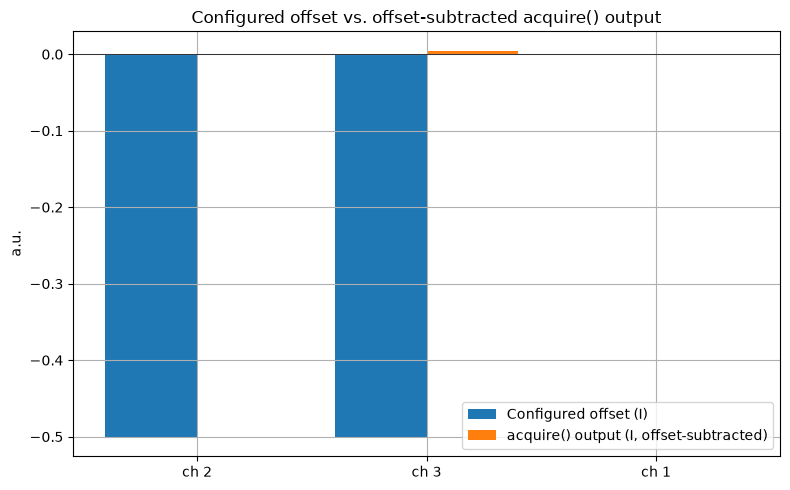


Note: acquire()/acquire_decimated() subtract the configured offset automatically.
get_raw() (the raw, pre-subtraction view used on hardware) is not available on QickEmu.


In [10]:
class TestProgram(AveragerProgramV2):
    """Signal-free program: readout-only, to check the offset-subtracted baseline."""

    def _initialize(self, cfg):
        # EMULATOR WORKAROUND: a program with zero declared generator pulses
        # has an empty waveform memory (`wmem`), and QickEmu.prepare() crashes
        # trying to export it (print_wmem2hex() assumes a non-None list). This
        # dummy pulse is declared but never played in _body() -- it exists
        # purely to give wmem one entry.
        self.declare_gen(ch=FSGEN_CH, nqz=1)
        self.add_pulse(ch=FSGEN_CH, name="_unused", style="const",
                       freq=100, length=0.01, phase=0, gain=0.0)

        for ch in cfg['ro_chs']:
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=100)

    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], t=0.0)

# HW version uses ro_len=100.0, reps=1000; shrunk for the emulator (deterministic
# simulation -- there's no thermal noise to average down, see Section 1).
config_offsets = {
    'ro_chs': MUXRO_CH + [STDRO_CH],
    'ro_len': 2.0,  # us
}

print("Configured IQ offsets (what acquire() subtracts internally):")
offsets = {}
for ch in config_offsets['ro_chs']:
    offset = soccfg['readouts'][ch]['iq_offset']
    offsets[ch] = offset
    print(f"  ch {ch}: {offset}")

print("\nRunning a signal-free acquisition (no pulse played) to check the corrected baseline...")
prog = TestProgram(soccfg, reps=50, final_delay=0.5, cfg=config_offsets)

OUT = ARTIFACTS_ROOT / 'iq_offsets'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)

iq_list = prog.acquire(soc, rounds=1)

fig, ax = plt.subplots(figsize=(8, 5))
chs = list(prog.ro_chs.keys())
configured = [offsets[ch] if not isinstance(offsets[ch], (list, tuple)) else offsets[ch][0] for ch in chs]
corrected_i = [float(iq_list[i][0, 0]) for i in range(len(chs))]
x = np.arange(len(chs))
ax.bar(x - 0.2, configured, width=0.4, label='Configured offset (I)')
ax.bar(x + 0.2, corrected_i, width=0.4, label='acquire() output (I, offset-subtracted)')
ax.set_xticks(x)
ax.set_xticklabels([f"ch {ch}" for ch in chs])
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel("a.u.")
ax.legend()
ax.set_title("Configured offset vs. offset-subtracted acquire() output")
ax.grid(True)
plt.tight_layout()
plt.show()

print("\nNote: acquire()/acquire_decimated() subtract the configured offset automatically.")
print("get_raw() (the raw, pre-subtraction view used on hardware) is not available on QickEmu.")

## 8. Performance Benchmarks

**Emulator note:** on hardware, this section benchmarks real acquisition throughput (shots/sec against the physical board). On the emulator, `acquire()` launches a Verilator simulation, so these numbers measure **simulation** throughput instead -- a fundamentally different thing, dominated by the fixed cost of spinning up the compiled testbench binary rather than the modeled acquisition electronics. Treat this as "how fast does this pattern simulate", not "how fast is this readout type on real hardware". `FASTDYNRO_CH` doesn't exist in this config (Section 6), so it's dropped from the comparison, and `reps` is shrunk from 1000 to 200 to keep this tractable.

In [11]:
def benchmark_readout(readout_ch, readout_type, ro_len=1.0, reps=200):
    """Benchmark different readout configurations (simulation throughput, see note above)."""
    class BenchProgram(AveragerProgramV2):
        def _initialize(self, cfg):
            # EMULATOR WORKAROUND: see the note in the Section 7 TestProgram above.
            self.declare_gen(ch=FSGEN_CH, nqz=1)
            self.add_pulse(ch=FSGEN_CH, name="_unused", style="const",
                           freq=100, length=0.01, phase=0, gain=0.0)
            self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'], freq=100)
        def _body(self, cfg):
            self.trigger(ros=[cfg['ro_ch']], t=0)

    cfg = {'ro_ch': readout_ch, 'ro_len': ro_len}
    prog = BenchProgram(soccfg, reps=reps, final_delay=0, cfg=cfg)

    start = time.time()
    prog.acquire(soc, rounds=1)
    elapsed = time.time() - start

    return elapsed, reps / elapsed  # shots per second (simulated)

print("Benchmarking different readout types (simulation throughput)...")
print("-" * 60)

OUT = ARTIFACTS_ROOT / 'benchmarks'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)

benchmarks = []
for ro_ch, name in [(STDRO_CH, "Standard"), (DYNRO_CH, "Dynamic")]:
    try:
        elapsed, rate = benchmark_readout(ro_ch, name)
        benchmarks.append((name, elapsed, rate))
        print(f"{name:15} Readout: {elapsed:.3f}s for 200 shots ({rate:.0f} shots/sec, simulated)")
    except Exception as e:
        print(f"{name:15} Readout: Error - {e}")

# Benchmark muxed readout (multiple channels)
class BenchMuxProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        # EMULATOR WORKAROUND: see the note in the Section 7 TestProgram above.
        self.declare_gen(ch=FSGEN_CH, nqz=1)
        self.add_pulse(ch=FSGEN_CH, name="_unused", style="const",
                       freq=100, length=0.01, phase=0, gain=0.0)
        for ch in cfg['ro_chs']:
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=100)
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], t=0)

cfg_mux = {'ro_chs': MUXRO_CH, 'ro_len': 1.0}
prog_mux = BenchMuxProgram(soccfg, reps=200, final_delay=0, cfg=cfg_mux)
start = time.time()
prog_mux.acquire(soc, rounds=1)
elapsed_mux = time.time() - start
print(f"{'Muxed (4 ch)':15} Readout: {elapsed_mux:.3f}s for 200 shots ({200/elapsed_mux:.0f} shots/sec, simulated)")

print("\nPerformance Notes (emulator, not hardware):")
print("- These numbers reflect Verilator simulation speed, not real acquisition electronics.")
print("- Muxed readout processes multiple channels within the same simulated trigger window.")
print("- Longer readout lengths proportionally increase simulated device time (and wall-clock time).")

Benchmarking different readout types (simulation throughput)...
------------------------------------------------------------
[sim] Running simulation with EMU_DIR=../../artifacts/07_advanced_generators_and_readouts/benchmarks ...


Standard        Readout: 4.563s for 200 shots (44 shots/sec, simulated)
Dynamic         Readout: Error - readout 0 is dynamic (tProc-configured) - freq/phase/sel parameters are set using tProc instructions, not in declaration
[sim] Running simulation with EMU_DIR=../../artifacts/07_advanced_generators_and_readouts/benchmarks ...


Muxed (4 ch)    Readout: 4.811s for 200 shots (42 shots/sec, simulated)

Performance Notes (emulator, not hardware):
- These numbers reflect Verilator simulation speed, not real acquisition electronics.
- Muxed readout processes multiple channels within the same simulated trigger window.
- Longer readout lengths proportionally increase simulated device time (and wall-clock time).


## 9. Real-Time Phase Tracking Example

**Skipped (adapted to a short note) on the emulator.** On hardware, this section tracks shot-to-shot phase stability using `prog.get_raw()` to recover per-rep IQ data. As established in Section 7, `get_raw()` always returns `None` against `QickEmu`, so the per-shot recovery this section depends on isn't available.

Even if it were: the emulator's simulation is fully deterministic given fixed inputs (see Section 1), so every one of the `n_shots` repetitions of an identical program would return byte-identical data -- `Phase stability` would read exactly 0.000 degrees RMS, which demonstrates the emulator's determinism rather than anything about phase tracking. Real shot-to-shot noise characterization needs real hardware (or a noise model the emulator doesn't currently implement).